In [ ]:
# Step 1 - Install all dependencies

!pip install -q transformers=4.45.0 datasets accelerate peft==0.13.0 trl==0.11.4 sentencepiece evaluate rouge_score bert_score huggingface_hub bitsandbytes

import torch, transformers, peft, trl, bitsandbytes
print("Transformers :", transformers.__version__)
print("PEFT         :", peft.__version__)
print("TRL          :", trl.__version__)
print("Bitsandbytes :", bitsandbytes.__version__)
print("Torch        :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 22.8 MB/s eta 0:00:00
Transformers : 5.0.0
PEFT         : 0.13.0
TRL          : 0.11.4
Bitsandbytes : 0.49.2
Torch        : 2.10.0+cu128
CUDA         : True


In [ ]:
# Step 2 - Check GPU

import torch

print("GPU available  :", torch.cuda.is_available())
print("GPU name       :", torch.cuda.get_device_name(0))
print("GPU memory     :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
print("Torch version  :", torch.__version__)

GPU available  : True
GPU name       : NVIDIA A100-SXM4-40GB
GPU memory     : 42.4 GB
Torch version  : 2.10.0+cu128


In [ ]:
# Step 3 - Mount Drive and Set Paths

import os
from google.colab import drive

drive.mount('/content/drive')

base_path       = '/content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG'
adapter_path    = base_path + '/Gemma2_2B_IT_QLoRA/adapter'
results_path    = base_path + '/Gemma2_2B_IT_QLoRA/results'
plots_path      = base_path + '/Gemma2_2B_IT_QLoRA/plots'
checkpoint_path = base_path + '/Gemma2_2B_IT_QLoRA/checkpoints'

for path in [adapter_path, results_path, plots_path, checkpoint_path]:
    os.makedirs(path, exist_ok=True)

print("Drive mounted successfully")
print("Adapter path   :", adapter_path)
print("Results path   :", results_path)
print("Checkpoint path:", checkpoint_path)

Mounted at /content/drive
Drive mounted successfully
Adapter path   : /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/Gemma2_2B_IT_QLoRA/adapter
Results path   : /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/Gemma2_2B_IT_QLoRA/results
Checkpoint path: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/Gemma2_2B_IT_QLoRA/checkpoints


In [ ]:
# Step 4 - HF Authentication and Load Dataset

import json
from google.colab import userdata
from huggingface_hub import login, hf_hub_download
from datasets import load_dataset

HF_TOKEN = userdata.get("HF_TOKEN")
login(HF_TOKEN)

ontology_file = hf_hub_download(
    repo_id   = "BSVGK/Text_to_KG_Construction_Dataset",
    filename  = "processed/ontology_schema.json",
    repo_type = "dataset",
    token     = HF_TOKEN
)
with open(ontology_file, 'r') as f:
    ontology = json.load(f)

print("Ontology loaded:", list(ontology.keys()))

dataset = load_dataset(
    "BSVGK/Text_to_KG_Construction_Dataset",
    data_files = {
        "train"      : "processed/train.jsonl",
        "validation" : "processed/validation.jsonl",
        "test"       : "processed/test.jsonl"
    },
    token = HF_TOKEN
)

print("Dataset loaded successfully")
print("Train records     :", len(dataset['train']))
print("Validation records:", len(dataset['validation']))
print("Test records      :", len(dataset['test']))

sample = dataset['train'][0]
print("\nSample Input:")
print(sample['input'])
print("\nSample Output (triples):")
for line in sample['output'].strip().split('\n'):
    print(line)

Ontology loaded: ['classes', 'relationships']


Repo card metadata block was not found. Setting CardData to empty.


Dataset loaded successfully
Train records     : 6470
Validation records: 1387
Test records      : 1387

Sample Input:
A £420850 contract identified as Contract_008672 in Yorkshire and the Humber was awarded to AMALGAMATED CONSTRUCTION LTD by Wakefield Council Customer Service. The award date was 2017-12-05, and the contract is associated with CPV code 71322000 for Engineering design services for the construction of civil engineering works.

Sample Output (triples):
(Contract_008672, rdf:type, Contract)
(Contract_008672, hasBuyer, Wakefield Council Customer Service)
(Contract_008672, hasSupplier, AMALGAMATED CONSTRUCTION LTD)
(Contract_008672, hasContractValue, 420850)
(Contract_008672, hasAwardDate, 2017-12-05)
(Contract_008672, hasCPVCode, 71322000)
(Contract_008672, hasCPVDescription, Engineering design services for the construction of civil engineering works)
(Contract_008672, hasLocation, Yorkshire and the Humber)


In [ ]:
# Step 5 - Load Tokenizer and Model in 4-bit

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "google/gemma-2-2b-it"

# Load tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code = True,
    token             = HF_TOKEN,
    padding_side      = "right"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
print("Tokenizer loaded")
print("Pad token  :", tokenizer.pad_token)
print("EOS token  :", tokenizer.eos_token)

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.bfloat16,
    bnb_4bit_use_double_quant = True,
)

# Load model in 4-bit
print("\nLoading model in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config = bnb_config,
    device_map          = "auto",
    trust_remote_code   = True,
    token               = HF_TOKEN,
    attn_implementation = "eager",
)
model.config.use_cache = False

total_params = sum(p.numel() for p in model.parameters())
print("Model loaded successfully")
print("Total parameters :", round(total_params / 1e9, 2), "B")
print("Memory used      :", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

Loading tokenizer...


Tokenizer loaded
Pad token  : <pad>
EOS token  : <eos>

Loading model in 4-bit...


Model loaded successfully
Total parameters : 1.6 B
Memory used      : 2.28 GB


In [ ]:
# Step 6 - Apply QLoRA Configuration

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

# Prepare model for 4-bit training
model = prepare_model_for_kbit_training(model)

# Define LoRA configuration
qlora_config = LoraConfig(
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
    target_modules = [
        "q_proj", "k_proj", "v_proj",
        "o_proj", "gate_proj",
        "up_proj", "down_proj"
    ]
)

model = get_peft_model(model, qlora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())

print("QLoRA applied successfully")
print("Trainable parameters :", f"{trainable_params:,}")
print("Total parameters     :", f"{total_params:,}")
print("Trainable percentage :", round(100 * trainable_params / total_params, 4), "%")
print("Memory used          :", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

QLoRA applied successfully
Trainable parameters : 20,766,720
Total parameters     : 1,622,970,624
Trainable percentage : 1.2795 %
Memory used          : 3.54 GB


In [ ]:
# Step 7 - Prepare Dataset and Prompt Format

def format_prompt(example):
    prompt = f"""<start_of_turn>user
{example['instruction']}

Contract Description:
{example['input']}<end_of_turn>
<start_of_turn>model
{example['output']}<end_of_turn>"""
    return {"text": prompt}

print("Formatting dataset...")
train_dataset = dataset['train'].map(format_prompt,      remove_columns=dataset['train'].column_names)
val_dataset   = dataset['validation'].map(format_prompt, remove_columns=dataset['validation'].column_names)
test_dataset  = dataset['test'].map(format_prompt,       remove_columns=dataset['test'].column_names)

print("Dataset formatted successfully")
print("Train records     :", len(train_dataset))
print("Validation records:", len(val_dataset))
print("Test records      :", len(test_dataset))

Formatting dataset...


Dataset formatted successfully
Train records     : 6470
Validation records: 1387
Test records      : 1387


In [ ]:
# Step 8 - Configure Training Arguments

from trl import SFTConfig

training_args = SFTConfig(
    output_dir                  = checkpoint_path,
    num_train_epochs            = 3,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = 4,
    learning_rate               = 2e-4,
    lr_scheduler_type           = "cosine",
    warmup_ratio                = 0.05,
    weight_decay                = 0.01,
    max_grad_norm               = 0.3,
    logging_steps               = 10,
    eval_steps                  = 100,
    save_steps                  = 100,
    optim                       = "paged_adamw_8bit",
    bf16                        = True,
    fp16                        = False,
    dataset_text_field          = "text",
    eval_strategy               = "steps",
    save_strategy               = "steps",
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    save_total_limit            = 2,
    report_to                   = "none",
    packing                     = False,
)

print("Training arguments configured successfully")
print("Epochs          :", training_args.num_train_epochs)
print("Batch size      :", training_args.per_device_train_batch_size)
print("Effective batch :", training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
print("Optimizer       :", training_args.optim)
print("BF16            :", training_args.bf16)

Training arguments configured successfully
Epochs          : 3
Batch size      : 4
Effective batch : 16
Optimizer       : OptimizerNames.PAGED_ADAMW_8BIT
BF16            : True


In [ ]:
# Step 9 - Initialize Trainer

from trl import SFTTrainer

trainer = SFTTrainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    tokenizer     = tokenizer,
)

total_steps = (len(train_dataset) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)) * training_args.num_train_epochs

print("Trainer initialized successfully")
print("Total training samples :", len(train_dataset))
print("Total training steps   :", total_steps)

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:292: UserWarning: You didn't pass a `max_seq_length` argument to the SFTTrainer, this will default to 1024
  warnings.warn(


Trainer initialized successfully
Total training samples : 6470
Total training steps   : 1212


In [ ]:
# Step 10 - Start Training

import time

start_time = time.time()

print("Starting training...")
print("Model         : Gemma 2 2B IT")
print("Method        : QLoRA")
print("Epochs        : 3")
print("Total steps   : 1212")
print("Logging every : 10 steps")
print("Eval every    : 100 steps")
print("-" * 50)

train_result = trainer.train()

end_time   = time.time()
total_time = round((end_time - start_time) / 60, 2)

print("-" * 50)
print("Training completed successfully")
print("Total steps   :", train_result.global_step)
print("Training loss :", round(train_result.training_loss, 4))
print("Training time :", total_time, "minutes")

Starting training...
Model         : Gemma 2 2B IT
Method        : QLoRA
Epochs        : 3
Total steps   : 1212
Logging every : 10 steps
Eval every    : 100 steps
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,0.307600,0.302338
200,0.274900,0.277821
300,0.266100,0.268194
400,0.260100,0.261469
500,0.239800,0.260276
600,0.241400,0.256233
700,0.233900,0.253647
800,0.229500,0.251329
900,0.212000,0.257592
1000,0.208900,0.256475


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

--------------------------------------------------
Training completed successfully
Total steps   : 1212
Training loss : 0.2689
Training time : 62.37 minutes


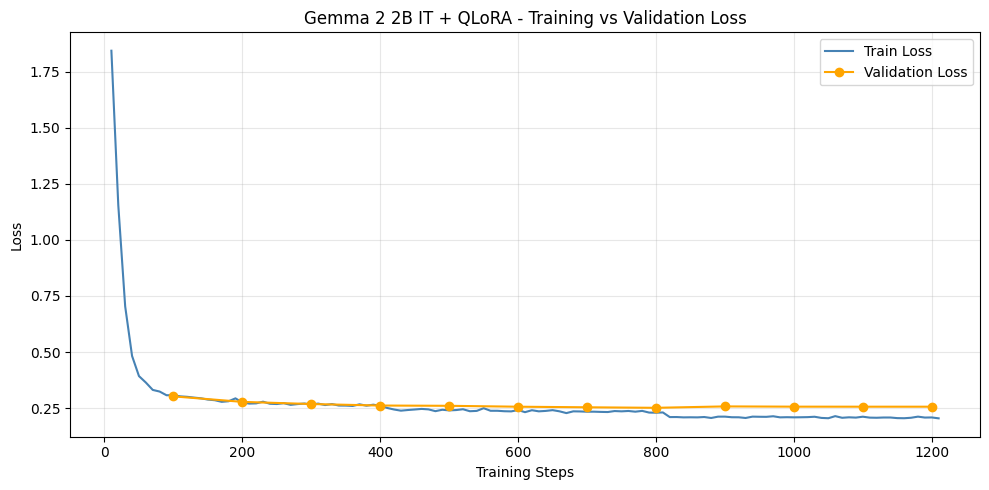

Loss curve saved

Saving QLoRA adapter to Drive...
Adapter saved to: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/Gemma2_2B_IT_QLoRA/adapter

Saved files:
  README.md : 0.01 MB
  adapter_model.safetensors : 83.12 MB
  adapter_config.json : 0.0 MB
  tokenizer_config.json : 0.05 MB
  special_tokens_map.json : 0.0 MB
  tokenizer.model : 4.24 MB
  tokenizer.json : 34.36 MB


In [ ]:
# Step 11 - Save Training Plots and Adapter

import matplotlib.pyplot as plt
import os

# Extract loss values from trainer log history
train_losses = [(x['step'], x['loss'])      for x in trainer.state.log_history if 'loss' in x]
eval_losses  = [(x['step'], x['eval_loss']) for x in trainer.state.log_history if 'eval_loss' in x]

train_steps, train_loss_values = zip(*train_losses)
eval_steps,  eval_loss_values  = zip(*eval_losses)

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss_values, label='Train Loss',      color='steelblue')
plt.plot(eval_steps,  eval_loss_values,  label='Validation Loss', color='orange', marker='o')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Gemma 2 2B IT + QLoRA - Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_path + '/loss_curve.png', dpi=150)
plt.show()
print("Loss curve saved")

# Save QLoRA adapter to Drive
print("\nSaving QLoRA adapter to Drive...")
trainer.model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print("Adapter saved to:", adapter_path)
print("\nSaved files:")
for f in os.listdir(adapter_path):
    size = os.path.getsize(os.path.join(adapter_path, f)) / 1e6
    print(f"  {f} : {round(size, 2)} MB")

In [ ]:
# Step 12 - Test Single Inference (Fixed)

import torch

# Set model to evaluation mode
model.eval()
model.config.use_cache = True

# Pick one sample from test set
sample = dataset['test'][0]

# Build prompt without output
prompt = f"""<start_of_turn>user
{sample['instruction']}

Contract Description:
{sample['input']}<end_of_turn>
<start_of_turn>model
"""

# Tokenize
inputs = tokenizer(
    prompt,
    return_tensors = "pt",
    truncation     = True,
    max_length     = 800
).to(model.device)

# Generate prediction with cache disabled to avoid dtype mismatch
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens     = 200,
        do_sample          = False,
        repetition_penalty = 1.1,
        pad_token_id       = tokenizer.pad_token_id,
        eos_token_id       = tokenizer.eos_token_id,
        use_cache          = False,
    )

# Decode only new tokens
input_length = inputs.input_ids.shape[1]
predicted    = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens = True
).strip()

print("Input:")
print(sample['input'])
print("\nPredicted Triples:")
print(predicted)
print("\nGround Truth:")
for line in sample['output'].strip().split('\n'):
    print(line)

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, 

Input:
Greater London Authority selected Happy Energy Solutions Ltd for contract Contract_001489 in London. The work is described as Heating works, with CPV code 45232141, awarded on 2019-12-10, and valued at £13970000.

Predicted Triples:
(Contract_001489, rdf:type, Contract)
(Contract_001489, hasBuyer, Greater London Authority)
(Contract_001489, hasSupplier, Happy Energy Solutions Ltd)
(Contract_001489, hasContractValue, 13970000)
(Contract_001489, hasAwardDate, 2019-12-10)
(Contract_001489, hasCPVCode, 45232141)
(Contract_001489, hasCPVDescription, Heating works)
(Contract_001489, hasLocation, London)

Ground Truth:
(Contract_001489, rdf:type, Contract)
(Contract_001489, hasBuyer, Greater London Authority)
(Contract_001489, hasSupplier, Happy Energy Solutions Ltd)
(Contract_001489, hasContractValue, 13970000)
(Contract_001489, hasAwardDate, 2019-12-10)
(Contract_001489, hasCPVCode, 45232141)
(Contract_001489, hasCPVDescription, Heating works)
(Contract_001489, hasLocation, London)


In [ ]:
# Step 13 - Full Batch Inference on All Test Records (Batch Size 8)

import torch
from torch.utils.data import DataLoader

model.eval()
model.config.use_cache = False

predictions  = []
ground_truths = []

# Prepare all prompts
all_prompts = []
for sample in dataset['test']:
    prompt = f"""<start_of_turn>user
{sample['instruction']}

Contract Description:
{sample['input']}<end_of_turn>
<start_of_turn>model
"""
    all_prompts.append(prompt)
    ground_truths.append(sample['output'].strip())

# Set padding side to left for batch generation
tokenizer.padding_side = "left"

batch_size = 8
total      = len(all_prompts)

print(f"Running batch inference...")
print(f"Total records : {total}")
print(f"Batch size    : {batch_size}")
print(f"Total batches : {(total + batch_size - 1) // batch_size}")
print("-" * 40)

for batch_start in range(0, total, batch_size):
    batch_prompts = all_prompts[batch_start : batch_start + batch_size]

    # Tokenize batch
    inputs = tokenizer(
        batch_prompts,
        return_tensors = "pt",
        padding        = True,
        truncation     = True,
        max_length     = 800
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens     = 200,
            do_sample          = False,
            repetition_penalty = 1.1,
            pad_token_id       = tokenizer.pad_token_id,
            eos_token_id       = tokenizer.eos_token_id,
            use_cache          = False,
        )

    # Decode only new tokens for each item in batch
    for j in range(len(batch_prompts)):
        input_length = inputs.input_ids.shape[1]
        predicted    = tokenizer.decode(
            outputs[j][input_length:],
            skip_special_tokens = True
        ).strip()
        predictions.append(predicted)

    # Progress update
    completed = min(batch_start + batch_size, total)
    print(f"Completed {completed} / {total} records")

print("\nInference completed")
print("Total predictions :", len(predictions))
print("Total ground truths:", len(ground_truths))

# Quick sanity check on first prediction
print("\nSample prediction:")
print(predictions[0])
print("\nSample ground truth:")
print(ground_truths[0])

Running batch inference...
Total records : 1387
Batch size    : 8
Total batches : 174
----------------------------------------
Completed 8 / 1387 records
Completed 16 / 1387 records
Completed 24 / 1387 records
Completed 32 / 1387 records
Completed 40 / 1387 records
Completed 48 / 1387 records
Completed 56 / 1387 records
Completed 64 / 1387 records
Completed 72 / 1387 records
Completed 80 / 1387 records
Completed 88 / 1387 records
Completed 96 / 1387 records
Completed 104 / 1387 records
Completed 112 / 1387 records
Completed 120 / 1387 records
Completed 128 / 1387 records
Completed 136 / 1387 records
Completed 144 / 1387 records
Completed 152 / 1387 records
Completed 160 / 1387 records
Completed 168 / 1387 records
Completed 176 / 1387 records
Completed 184 / 1387 records
Completed 192 / 1387 records
Completed 200 / 1387 records
Completed 208 / 1387 records
Completed 216 / 1387 records
Completed 224 / 1387 records
Completed 232 / 1387 records
Completed 240 / 1387 records
Completed 248 / 

In [ ]:
# Step 14a - Export All Predictions to CSV

import csv

csv_path = results_path + '/predictions.csv'

fieldnames = ['record_id', 'input', 'ground_truth', 'prediction']

with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for i, (pred, gt) in enumerate(zip(predictions, ground_truths)):
        writer.writerow({
            'record_id'   : i + 1,
            'input'       : dataset['test'][i]['input'],
            'ground_truth': gt,
            'prediction'  : pred,
        })

print("Predictions CSV saved to:", csv_path)
print("Total records saved     :", len(predictions))

Predictions CSV saved to: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/Gemma2_2B_IT_QLoRA/results/predictions.csv
Total records saved     : 1387


In [ ]:
# Step 14b - Compute All Metrics and Save to Drive

import csv
import numpy as np
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

def parse_triples(text):
    triples = set()
    for line in text.strip().split('\n'):
        line = line.strip()
        if line.startswith('(') and line.endswith(')'):
            triples.add(line.lower())
    return triples

VALID_PREDICATES = {
    "rdf:type", "hasbuyer", "hassupplier", "hascontractvalue",
    "hasawarddate", "hascpvcode", "hascpvdescription", "haslocation"
}

def check_hallucination_l1(predicted_text):
    for line in predicted_text.strip().split('\n'):
        line = line.strip()
        if line.startswith('(') and line.endswith(')'):
            parts = line[1:-1].split(',')
            if len(parts) >= 2:
                predicate = parts[1].strip().lower()
                if predicate not in VALID_PREDICATES:
                    return 1
    return 0

def check_hallucination_l2(predicted_text, input_text):
    input_lower = input_text.lower()
    for line in predicted_text.strip().split('\n'):
        line = line.strip()
        if line.startswith('(') and line.endswith(')'):
            parts = line[1:-1].split(',', 2)
            if len(parts) == 3:
                obj = parts[2].strip().lower()
                if obj and obj not in input_lower and obj not in VALID_PREDICATES:
                    return 1
    return 0

print("Computing metrics...")

f1_scores        = []
precision_scores = []
recall_scores    = []
rouge_scores     = []
hall_l1_scores   = []
hall_l2_scores   = []
results_rows     = []

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

for i, (pred, gt) in enumerate(zip(predictions, ground_truths)):
    pred_triples = parse_triples(pred)
    gt_triples   = parse_triples(gt)

    if len(pred_triples) == 0 and len(gt_triples) == 0:
        p, r, f1 = 1.0, 1.0, 1.0
    elif len(pred_triples) == 0 or len(gt_triples) == 0:
        p, r, f1 = 0.0, 0.0, 0.0
    else:
        tp = len(pred_triples & gt_triples)
        p  = tp / len(pred_triples)
        r  = tp / len(gt_triples)
        f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

    rouge_l = scorer.score(gt, pred)['rougeL'].fmeasure
    h_l1    = check_hallucination_l1(pred)
    h_l2    = check_hallucination_l2(pred, dataset['test'][i]['input'])

    f1_scores.append(f1)
    precision_scores.append(p)
    recall_scores.append(r)
    rouge_scores.append(rouge_l)
    hall_l1_scores.append(h_l1)
    hall_l2_scores.append(h_l2)

    results_rows.append({
        'record_id'        : i + 1,
        'input'            : dataset['test'][i]['input'],
        'ground_truth'     : gt,
        'prediction'       : pred,
        'precision'        : round(p, 4),
        'recall'           : round(r, 4),
        'f1'               : round(f1, 4),
        'rouge_l'          : round(rouge_l, 4),
        'hallucination_l1' : h_l1,
        'hallucination_l2' : h_l2,
    })

print("Computing BERTScore...")
P, R, F = bert_score_fn(
    predictions,
    ground_truths,
    lang       = "en",
    model_type = "distilbert-base-uncased",
    verbose    = False
)
bert_scores = F.tolist()

for i, row in enumerate(results_rows):
    row['bert_score'] = round(bert_scores[i], 4)

final_metrics = {
    'model'            : 'Gemma 2 2B IT',
    'method'           : 'QLoRA',
    'f1'               : round(np.mean(f1_scores), 4),
    'recall'           : round(np.mean(recall_scores), 4),
    'precision'        : round(np.mean(precision_scores), 4),
    'rouge_l'          : round(np.mean(rouge_scores), 4),
    'bert_score'       : round(np.mean(bert_scores), 4),
    'hallucination_l1' : round(np.mean(hall_l1_scores), 4),
    'hallucination_l2' : round(np.mean(hall_l2_scores), 4),
}

print("\nFinal Evaluation Results")
print("-" * 40)
print("Model            : Gemma 2 2B IT + QLoRA")
print("F1 Score         :", final_metrics['f1'])
print("Recall           :", final_metrics['recall'])
print("Precision        :", final_metrics['precision'])
print("ROUGE-L          :", final_metrics['rouge_l'])
print("BERTScore        :", final_metrics['bert_score'])
print("Hallucination L1 :", final_metrics['hallucination_l1'])
print("Hallucination L2 :", final_metrics['hallucination_l2'])

# Save per-record results with metrics to CSV
detailed_csv_path = results_path + '/predictions_with_metrics.csv'
fieldnames = [
    'record_id', 'input', 'ground_truth', 'prediction',
    'precision', 'recall', 'f1', 'rouge_l',
    'bert_score', 'hallucination_l1', 'hallucination_l2'
]
with open(detailed_csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results_rows)

print("\nDetailed CSV saved to   :", detailed_csv_path)

# Save summary metrics to CSV
metrics_path = results_path + '/metrics.csv'
with open(metrics_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=final_metrics.keys())
    writer.writeheader()
    writer.writerow(final_metrics)

print("Metrics CSV saved to    :", metrics_path)
print("All results saved successfully")

Computing metrics...
Computing BERTScore...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



Final Evaluation Results
----------------------------------------
Model            : Gemma 2 2B IT + QLoRA
F1 Score         : 0.9756
Recall           : 0.9688
Precision        : 0.9835
ROUGE-L          : 0.9783
BERTScore        : 0.9975
Hallucination L1 : 0.0036
Hallucination L2 : 0.1233

Detailed CSV saved to   : /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/Gemma2_2B_IT_QLoRA/results/predictions_with_metrics.csv
Metrics CSV saved to    : /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/Gemma2_2B_IT_QLoRA/results/metrics.csv
All results saved successfully
